In [1]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score, auc, precision_recall_curve, precision_score, recall_score
import matplotlib.pyplot as plt 

In [ ]:
tumor_data = np.load('data/RatTumorData_postGd_fit.npz')
tumor_masks = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')

In [3]:
imShape_tumor = tumor_masks['imageShape'][:-1]

test_fits = tumor_data['fits']
print(test_fits.shape)

tumor_voxelInds = tumor_masks['voxelInds_tumor']
tumor_healthyInds = tumor_masks['voxelInds_healthy']

voxelInds_im_tumor = np.zeros(imShape_tumor)
voxelInds_im_tumor = voxelInds_im_tumor.reshape(-1,1)
voxelInds_im_tumor[tumor_voxelInds] = 1
voxelInds_im_tumor = voxelInds_im_tumor.reshape(imShape_tumor)
print(voxelInds_im_tumor.shape)

voxelInds_im_healthy = np.zeros(imShape_tumor)
voxelInds_im_healthy = voxelInds_im_healthy.reshape(-1,1)
voxelInds_im_healthy[tumor_healthyInds] = 1
voxelInds_im_healthy = voxelInds_im_healthy.reshape(imShape_tumor)
print(voxelInds_im_healthy.shape)

(3, 192, 192, 15)
(3, 192, 192)
(3, 192, 192)


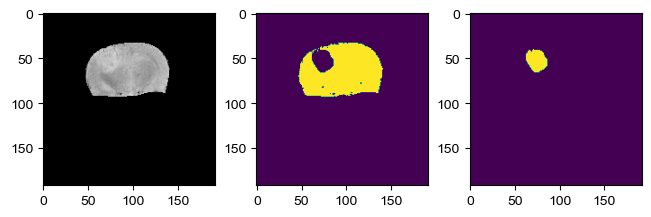

In [4]:
fig, ax = plt.subplots(1,3,layout='constrained')
ax[0].imshow(test_fits[1,:,:,0], cmap='gray', vmin=0, vmax=1)
ax[1].imshow(voxelInds_im_healthy[1,:,:])
ax[2].imshow(voxelInds_im_tumor[1,:,:])

In [5]:
n_features = test_fits.shape[-1]
test_data = test_fits[:-1].reshape(-1,n_features)
test_tumor_inds = voxelInds_im_tumor[:-1].reshape(-1)
test_healthy_inds = voxelInds_im_healthy[:-1].reshape(-1)

test_all_inds = test_tumor_inds + test_healthy_inds

X_test = test_data[test_all_inds.astype(bool)]

y_test = test_all_inds
y_test[test_tumor_inds.astype(bool)] = 2
y_test_inds = np.nonzero(y_test)[0]
y_test = y_test[y_test_inds] - 1
print(np.unique(y_test, return_counts=True))

(array([0., 1.]), array([8672,  648]))


In [6]:
# extract indices related to amplitude
amplitude_features = np.array([0,3,6,9,12])
X_test_amp = X_test[:,amplitude_features]

In [7]:
thresholds = {'DS': {}, 'MT': {}, 'APT': {}, 'Amine': {}, 'rNOE': {}}

In [8]:
for i, key in enumerate(thresholds):
    print(str(i) + ' corresponds to ' + str(key))

0 corresponds to DS
1 corresponds to MT
2 corresponds to APT
3 corresponds to Amine
4 corresponds to rNOE


In [9]:
_, counts = np.unique(y_test, return_counts=True)
print(counts)

[8672  648]


Text(0.5, 1.0, 'PR curve')

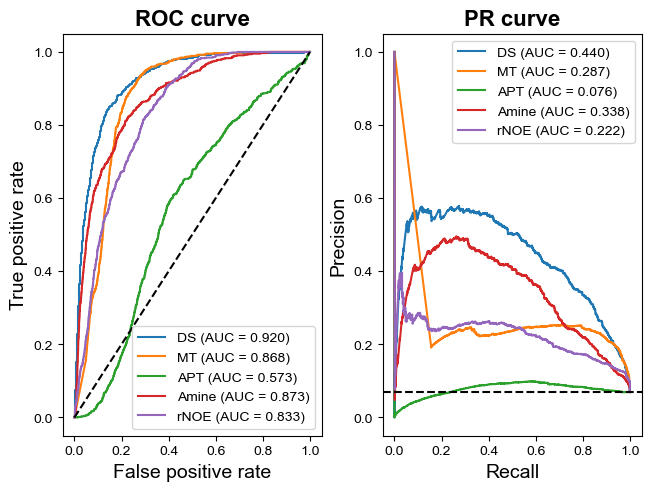

In [10]:
fig, ax = plt.subplots(1, 2, layout='constrained')

for i, key in enumerate(thresholds):
    X_test_amp_i = X_test_amp[:,i]
    if any(x in key for x in ['rNOE','Amine','MT']):
        X_test_amp_i = -X_test_amp_i
    
    fpr, tpr, threshold = roc_curve(y_test,X_test_amp_i)
    roc_auc = auc(fpr, tpr)
    thresholds[key]['F1'] = threshold
    
    label_for_curve = str(key) + ' (AUC = %0.3f)' %roc_auc
    ax[0].plot(fpr, tpr, label=label_for_curve)

    pr, rr, threshold = precision_recall_curve(y_test, X_test_amp_i)
    pr_auc = auc(rr, pr)
    thresholds[key]['PR'] = threshold
    
    label_for_curve = str(key) + ' (AUC = %0.3f)' %pr_auc
    ax[1].plot(rr, pr, label=label_for_curve)


ax[0].legend()
ax[0].plot([0,1],[0,1],'k--', label='Random classifier')
ax[0].set_xlabel('False positive rate', fontsize=14)
ax[0].set_ylabel('True positive rate', fontsize=14)
ax[0].set_title('ROC curve', fontweight='bold', fontsize=16)

ax[1].legend()
ax[1].axhline(y = counts[1] / np.sum(counts), color='k', linestyle='--', label='Random classifier')
ax[1].set_xlabel('Recall', fontsize=14)
ax[1].set_ylabel('Precision', fontsize=14)
ax[1].set_title('PR curve', fontweight='bold', fontsize=16)

In [14]:
fig.savefig('/Users/anshumanswain/Desktop/Fit_Amplitude_Metrics.jpg', dpi=300, bbox_inches='tight')

In [11]:
def best_f1(y_true, scores, thresholds):
    f1s = []

    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        f1s.append(f1_score(y_true,y_pred))
        
    best_idx = np.argmax(f1s)
    return thresholds[best_idx], f1s[best_idx]

In [13]:
for key in thresholds:
    X_test_amp_i = X_test_amp[:,i]
    if any(x in key for x in ['rNOE','Amine','MT']):
        X_test_amp_i = -X_test_amp_i

    best_thresh, f1 = best_f1(y_test, X_test_amp_i, thresholds[key]['F1'])
    y_pred = (X_test_amp_i >= best_thresh).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print('The best F1 score for ' + str(key) + ' : %0.3f'%f1)
    print('The best precision score for ' + str(key) + ' : %0.3f'%precision)
    print('The best recall score for ' + str(key) + ' : %0.3f'%recall)

The best F1 score for DS : 0.130
The best precision score for DS : 0.069
The best recall score for DS : 0.997
The best F1 score for MT : 0.335
The best precision score for MT : 0.244
The best recall score for MT : 0.535
The best F1 score for APT : 0.130
The best precision score for APT : 0.070
The best recall score for APT : 1.000
The best F1 score for Amine : 0.335
The best precision score for Amine : 0.244
The best recall score for Amine : 0.535
The best F1 score for rNOE : 0.338
The best precision score for rNOE : 0.247
The best recall score for rNOE : 0.534
